In [4]:
!python modul_01_image_io.py

In [5]:
!python modul_02_pixel.py

(300, 500, 3)


In [6]:
!python modul_03_threshold.py

In [7]:
!python modul_07_edge.py

In [8]:
!python modul_10_morphology.py

In [9]:
!python modul_11_segmentasi.py

In [10]:
!python modul_12_contour.py

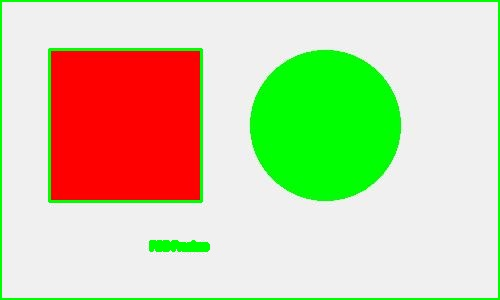

In [11]:
from IPython.display import Image

Image("output_pixel.jpg")
Image("threshold.jpg")
Image("edges.jpg")
Image("contour.jpg")

Jumlah objek terdeteksi: 50


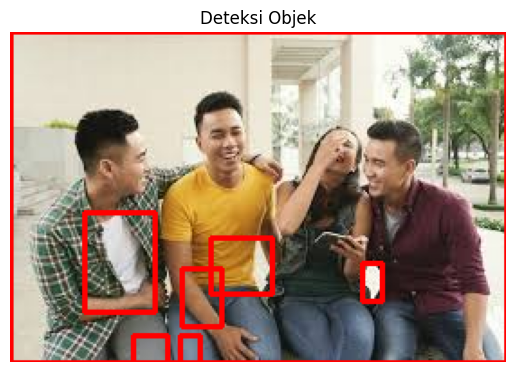

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar
img = cv2.imread('rice.jpg')

if img is None:
    print("Gambar tidak ditemukan!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Convert ke grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Blur untuk mengurangi noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # 4. Threshold (biner)
    _, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

    # 5. Cari kontur (objek)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    print("Jumlah objek terdeteksi:", len(contours))

    # 6. Gambar bounding box
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # Filter objek kecil (noise)
        if area > 100:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (255,0,0), 2)

    # 7. Tampilkan hasil
    plt.imshow(img_rgb)
    plt.title("Deteksi Objek")
    plt.axis("off")
    plt.show()